# LangGraph Multi-Agent (React) Collaboration

In [1]:
from dotenv import load_dotenv
load_dotenv() 

True

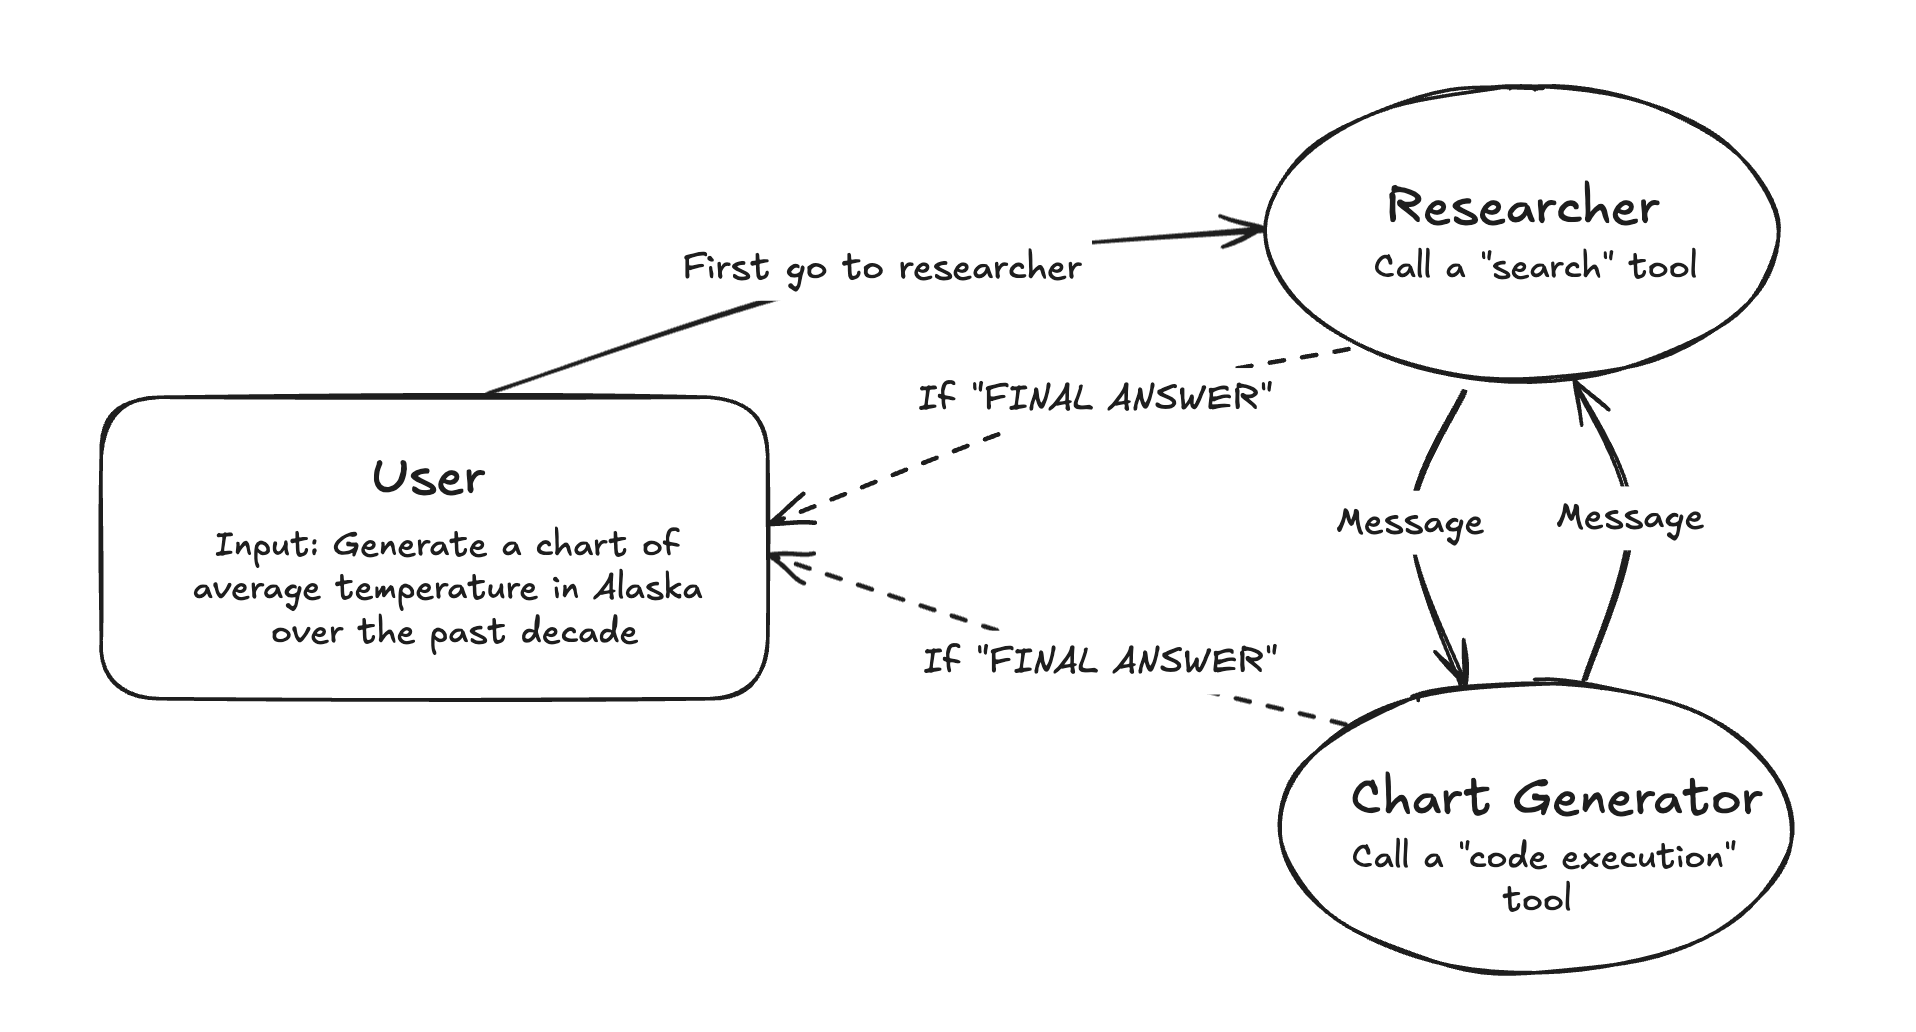

In [2]:
from IPython.display import Image
Image(filename='C:/Users/James/ice_breaker/images/multiagent.png', width=1000) 

### Define Tools for the Agents

In [3]:
from typing import Annotated

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

# 3PD tool for web searching/scraping 
tavily_tool = TavilySearchResults(max_results=5)

# Python code writer tool
# Warning: This executes code locally, which can be unsafe when not sandboxed
repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

### Define Agents & Graph Nodes

In [4]:
from typing import Literal

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState, END
from langgraph.types import Command

# Define the LLM
llm = ChatOpenAI(model="gpt-3.5-turbo") #"gpt-4o-mini"

# Helper function to determine the next step based on the content of the last message.
## If contains "FINAL ANSWER", per the prompt, "END" (complete) the process. 
def get_next_node(last_message: BaseMessage, goto: str):
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return END
    return goto

In [5]:
# Shared portion of the Agents' prompts. Agents will have their own specific "suffix"
def make_system_prompt(suffix: str) -> str:
    """Utility to create a system prompt for each agent"""
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{suffix}"
    )

# Research Agent
## Uses the shared llm, the `Tavily` websearch tool (`tavily_tool`), and a provided
## "suffix" to append to the shared prompt to provide specificity/focus.
research_agent = create_react_agent(
    llm,
    tools=[tavily_tool],
    prompt=make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    ),
)

# Research Node
## Create a node in the graph for the Research Agent
def research_node(
    state: MessagesState,
) -> Command[Literal["chart_generator", END]]:
    # Invoke the Research Agent with the current state ("scratchpad"); the Agent will 
    # update the scratchpad
    result = research_agent.invoke(state)
    # Use the helper function to read the last message on the scratchpad and then either
    # end (as complete) the process or move to the next node defined (here, the Chart 
    # Generator Agent). 
    goto = get_next_node(result["messages"][-1], "chart_generator")
    # Wrap the last message in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="researcher"
    )
    # Return a command that updates the message history and specifies the next node
    return Command(
        update={
            # Update the scratchpad with the internal message history of Research Agent
            # so it can be shared with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )


# Chart Generator Agent
## Uses the shared llm, the python code writer tool (`python_repl_tool`), and a provided
## "suffix" to append to the shared prompt to provide specificity/focus.
# NOTE: THIS PERFORMS ARBITRARY CODE EXECUTION, WHICH CAN BE UNSAFE WHEN NOT SANDBOXED
chart_agent = create_react_agent(
    llm,
    [python_repl_tool],
    prompt=make_system_prompt(
        "You can only generate charts. You are working with a researcher colleague."
    ),
)

# Chart Generator Node
## Create a node in the graph for the Chart Generator Agent
def chart_node(state: MessagesState) -> Command[Literal["researcher", END]]:
    # Invoke the Chart Generator Agent with the current state
    result = chart_agent.invoke(state)
    # Define the next step by using the helper function to either end (as complete)
    # the process or move to the next node defined (here, the Research Agent). 
    goto = get_next_node(result["messages"][-1], "researcher")
    # Wrap the last message in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="chart_generator"
    )
    # Return a command that updates the message history and specifies the next node

    return Command(
        update={
            # share internal message history of chart agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )

### Create the Graph
Set up a workflow using a state graph to manage the interaction between the Agents.

In [6]:
from langgraph.graph import StateGraph, START

# Initialize
workflow = StateGraph(MessagesState)
# Add the Agent Nodes
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)
# Add the Edge from the START node to the Researcher node
workflow.add_edge(START, "researcher")
# Compile the workflow into a graph structure for execution
graph = workflow.compile()

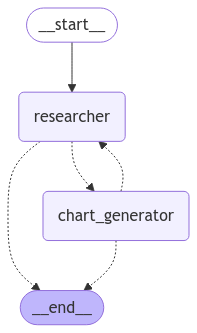

In [7]:
# Display the graph structure
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

### Invoke the Graph

{'researcher': {'messages': [HumanMessage(content='First, get the number of points scored by the Patriots in the last 10 seasons then make a line chart of it. Once you make the chart, finish.', additional_kwargs={}, response_metadata={}, id='2ab8c9a5-8ab8-4c50-97e2-f491358f8694'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_7XwMHueHuMON2KCnSn7g8Fzh', 'function': {'arguments': '{"query":"New England Patriots total points in the last 10 seasons"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 215, 'total_tokens': 244, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-b8e35670-912a-

Python REPL can execute arbitrary code. Use with caution.


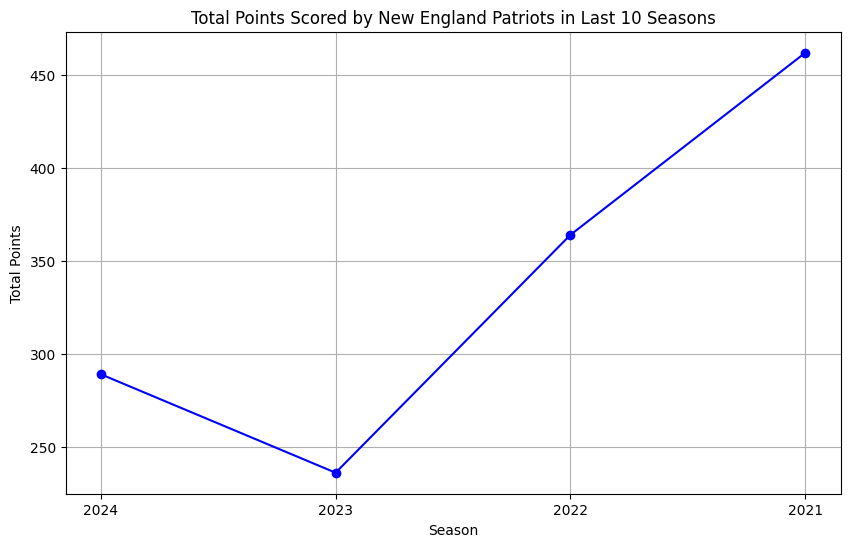

{'chart_generator': {'messages': [HumanMessage(content='First, get the number of points scored by the Patriots in the last 10 seasons then make a line chart of it. Once you make the chart, finish.', additional_kwargs={}, response_metadata={}, id='2ab8c9a5-8ab8-4c50-97e2-f491358f8694'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_7XwMHueHuMON2KCnSn7g8Fzh', 'function': {'arguments': '{"query":"New England Patriots total points in the last 10 seasons"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 215, 'total_tokens': 244, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-b8e35670-

In [8]:
events = graph.stream(
    {
        "messages": [
            (
                "user",
                "First, get the number of points scored by the Patriots in the last 10 seasons then make a line chart of it. "
                "Once you make the chart, finish.",
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 150},
)
for s in events:
    print(s)
    print("----")

In [9]:
events = graph.stream(
    {
        "messages": [
            (
                "user",
                "First, get the total snowfall Sunapee Mountain in each of the last 10 years then make a line chart of it. "
                "Once you make the chart, finish.",
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 150},
)
for s in events:
    print(s)
    print("----")

{'researcher': {'messages': [HumanMessage(content='First, get the total snowfall Sunapee Mountain in each of the last 10 years then make a line chart of it. Once you make the chart, finish.', additional_kwargs={}, response_metadata={}, id='6f619732-9294-43c6-9499-c35eb6e06b5d'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_AgYE0Fkm4MdElr6NKg3xQDm7', 'function': {'arguments': '{"query":"total snowfall Sunapee Mountain by year"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 217, 'total_tokens': 244, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-c1fcda33-7af2-47d0-b2b1-37f3c995d

{'researcher': {'messages': [HumanMessage(content='First, get the number of cars manufacture in the USA in the last 10 years then make a histogram of it. Once you make the chart, finish.', additional_kwargs={}, response_metadata={}, id='dcc2198b-ff80-4107-92c8-acc61d0705c0'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_4JEfvQuY1ilEj7uXp6XTO3Pj', 'function': {'arguments': '{"query":"number of cars manufactured in the USA in the last 10 years"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 214, 'total_tokens': 245, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-8689de22-6d42-48

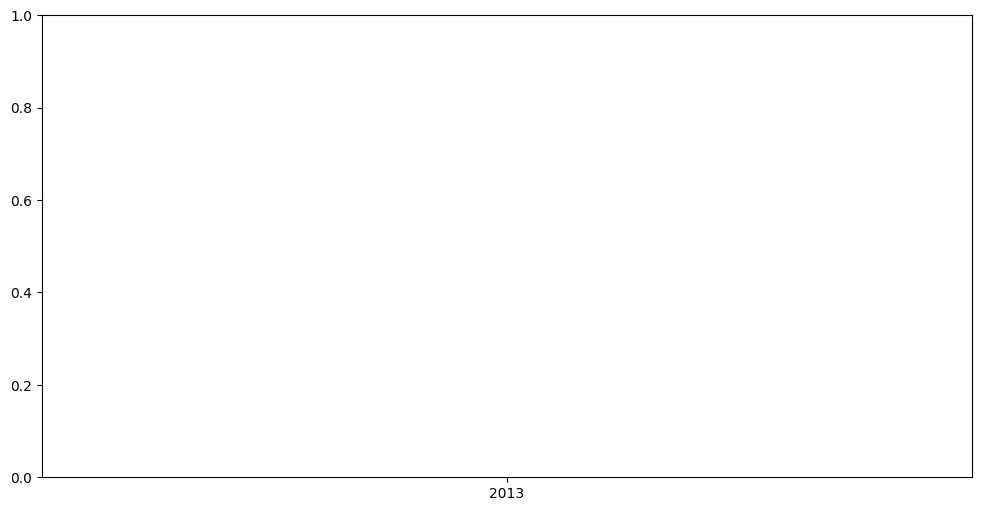

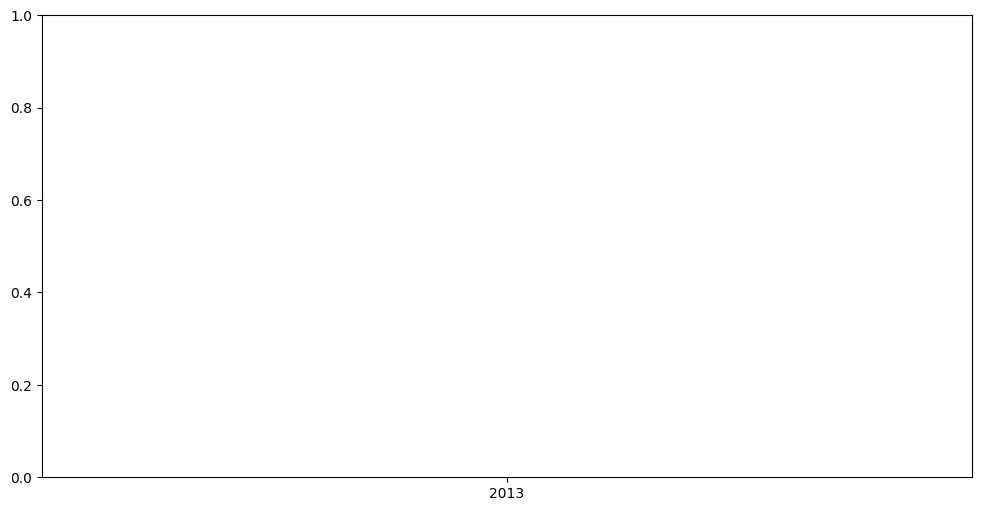

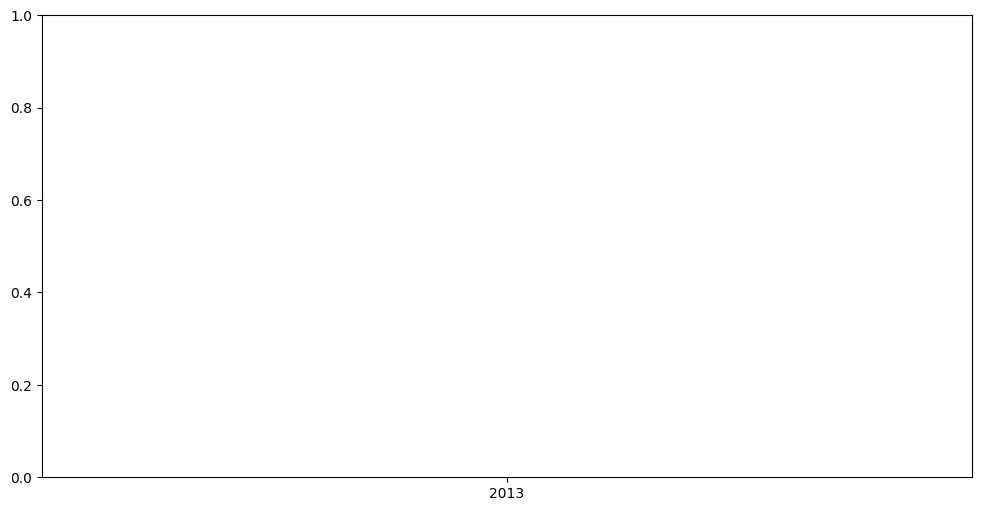

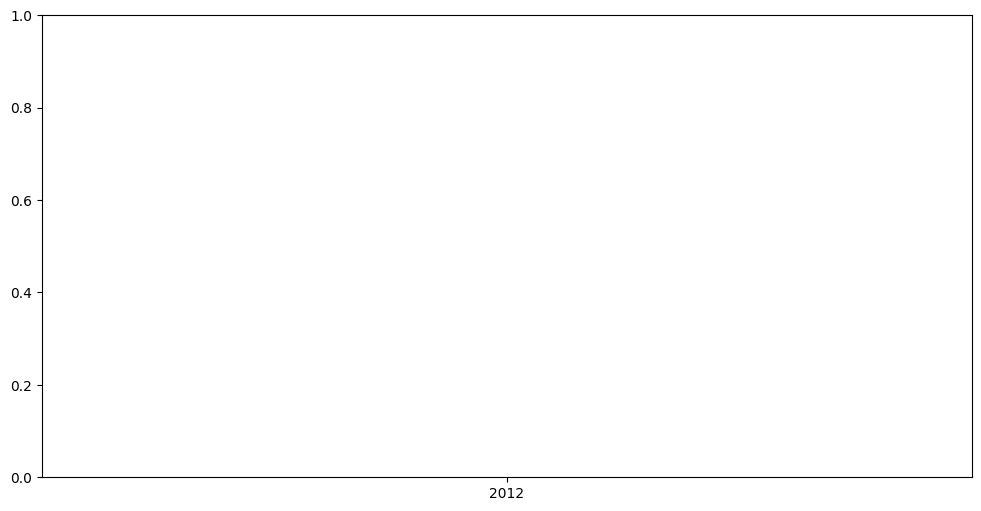

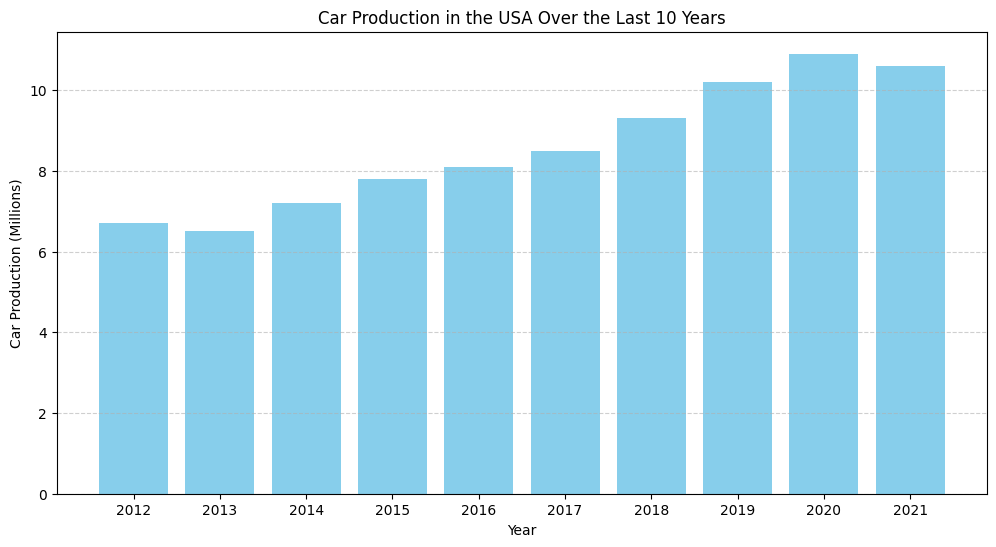

{'chart_generator': {'messages': [HumanMessage(content='First, get the number of cars manufacture in the USA in the last 10 years then make a histogram of it. Once you make the chart, finish.', additional_kwargs={}, response_metadata={}, id='dcc2198b-ff80-4107-92c8-acc61d0705c0'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_4JEfvQuY1ilEj7uXp6XTO3Pj', 'function': {'arguments': '{"query":"number of cars manufactured in the USA in the last 10 years"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 214, 'total_tokens': 245, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-8689de22-6d

In [10]:
events = graph.stream(
    {
        "messages": [
            (
                "user",
                "First, get the number of cars manufacture in the USA in the last 10 years then make a histogram of it. "
                "Once you make the chart, finish.",
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 150},
)
for s in events:
    print(s)
    print("----")